In [ ]:
import zipfile
import os

# Extract the Kaggle ZIP file
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/retail_data')

# See what files were extracted
os.listdir('/content/retail_data')

['retail_sales_dataset.csv']

In [ ]:
import pandas as pd

# Load the retail sales dataset
df = pd.read_csv('/content/retail_data/retail_sales_dataset.csv')

# Display the first 5 rows
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [ ]:
# Check dataset size
print("Rows and Columns:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types and non-null values
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())


Rows and Columns: (120000, 17)

Column Names:
['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9

In [ ]:
# Convert transaction_date to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check date range
print("\nDate range:")
print("Start:", df['transaction_date'].min())
print("End:", df['transaction_date'].max())

# Check basic statistics
print("\nBasic Statistics:")
display(df.describe())

Missing values:
transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

Duplicate rows: 0

Date range:
Start: 2024-01-01 00:00:00
End: 2025-12-30 00:00:00

Basic Statistics:


,transaction_date,quantity,unit_price,discount_pct,sales_amount
count,120000,120000.000000,120000.000000,120000.000000,120000.000000
mean,2024-12-30 12:00:54.720000,1.662908,240.621785,5.496500,377.975454
min,2024-01-01 00:00:00,1.000000,7.730000,0.000000,5.410000
25%,2024-06-30 00:00:00,1.000000,102.010000,0.000000,136.860000
50%,2024-12-31 00:00:00,1.000000,238.750000,0.000000,295.980000
75%,2025-07-02 00:00:00,2.000000,379.000000,10.000000,461.500000
max,2025-12-30 00:00:00,5.000000,493.510000,30.000000,2467.550000
std,NaN,1.014291,146.457057,8.193257,356.893357


In [ ]:
# Create useful time-based columns for analysis

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.month_name()
df['quarter'] = df['transaction_date'].dt.quarter

print("New columns created successfully!")

display(df.head())

New columns created successfully!


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,...,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,year,month,month_name,quarter
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,...,313.53,20,501.65,Debit Card,Online,North,2024,4,April,2
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,...,366.16,0,366.16,Credit Card,Online,South,2025,7,July,3
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,...,27.99,0,27.99,Gift Card,In-Store,South,2025,6,June,2
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,...,102.01,15,173.42,Cash,In-Store,South,2025,8,August,3
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,...,259.55,0,259.55,Cash,In-Store,Central,2024,12,December,4


In [ ]:
# Descriptive statistics for numerical columns

print("Descriptive Statistics:")
display(df.describe())

# Total sales
total_sales = df['sales_amount'].sum()

# Total quantity sold
total_quantity = df['quantity'].sum()

# Average transaction value
average_transaction = df['sales_amount'].mean()

print(f"\nTotal Sales: ₹{total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Transaction Value: ₹{average_transaction:,.2f}")

Descriptive Statistics:


,transaction_date,quantity,unit_price,discount_pct,sales_amount,year,month,quarter
count,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,2024-12-30 12:00:54.720000,1.662908,240.621785,5.496500,377.975454,2024.499150,6.506475,2.503225
min,2024-01-01 00:00:00,1.000000,7.730000,0.000000,5.410000,2024.000000,1.000000,1.000000
25%,2024-06-30 00:00:00,1.000000,102.010000,0.000000,136.860000,2024.000000,4.000000,2.000000
50%,2024-12-31 00:00:00,1.000000,238.750000,0.000000,295.980000,2024.000000,7.000000,3.000000
75%,2025-07-02 00:00:00,2.000000,379.000000,10.000000,461.500000,2025.000000,9.000000,3.000000
max,2025-12-30 00:00:00,5.000000,493.510000,30.000000,2467.550000,2025.000000,12.000000,4.000000
std,NaN,1.014291,146.457057,8.193257,356.893357,0.500001,3.445941,1.115818



Total Sales: ₹45,357,054.45
Total Quantity Sold: 199,549
Average Transaction Value: ₹377.98


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


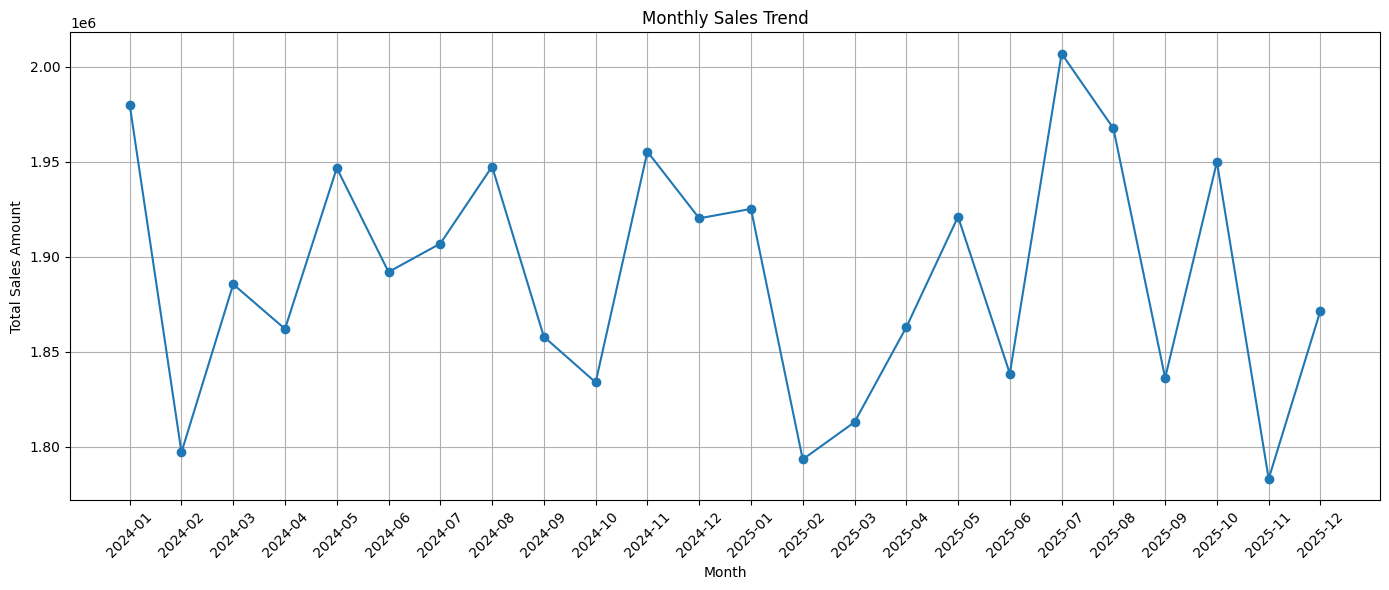

In [ ]:
# Monthly sales analysis

monthly_sales = df.groupby(
    ['year', 'month']
)['sales_amount'].sum().reset_index()

monthly_sales['period'] = (
    monthly_sales['year'].astype(str) + '-' +
    monthly_sales['month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['period'],
    monthly_sales['sales_amount'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

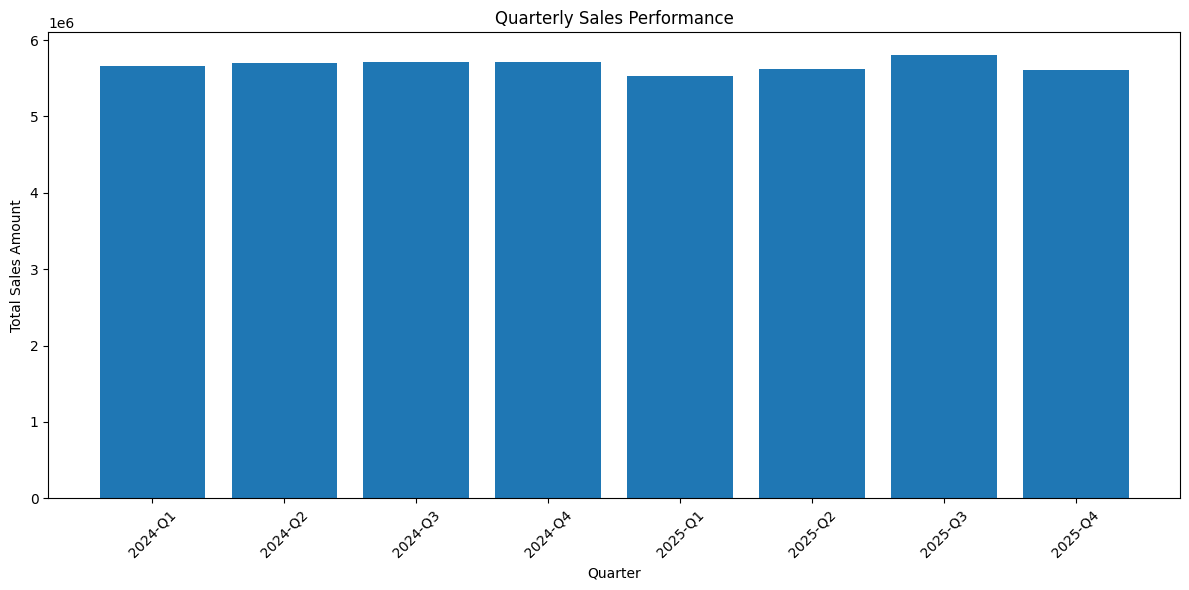

In [ ]:
# Quarterly Sales Analysis

quarterly_sales = df.groupby(
    ['year', 'quarter']
)['sales_amount'].sum().reset_index()

quarterly_sales['period'] = (
    quarterly_sales['year'].astype(str) +
    '-Q' +
    quarterly_sales['quarter'].astype(str)
)

plt.figure(figsize=(12, 6))

plt.bar(
    quarterly_sales['period'],
    quarterly_sales['sales_amount']
)

plt.title('Quarterly Sales Performance')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Category-wise Sales:


,sales_amount
category,
Beauty,6355718.23
Books,6005237.69
Sports,5863370.76
Electronics,5859686.69
Home,5655562.80
Toys,5557562.19
Groceries,5431536.64
Clothing,4628379.45


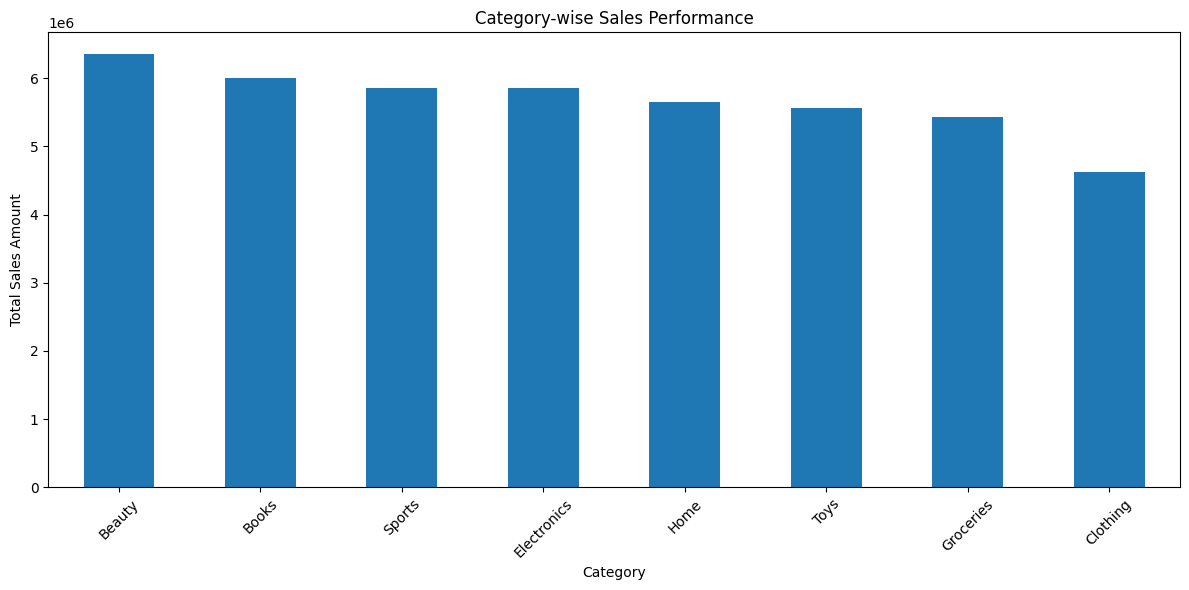

In [ ]:
# Category-wise Sales Analysis

category_sales = (
    df.groupby('category')['sales_amount']
      .sum()
      .sort_values(ascending=False)
)

print("Category-wise Sales:")
display(category_sales)

# Bar Chart
plt.figure(figsize=(12, 6))

category_sales.plot(kind='bar')

plt.title('Category-wise Sales Performance')
plt.xlabel('Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Customer Segment:


,sales_amount
customer_segment,
Loyal,11393721.23
New,11331906.60
VIP,11320171.31
Returning,11311255.31


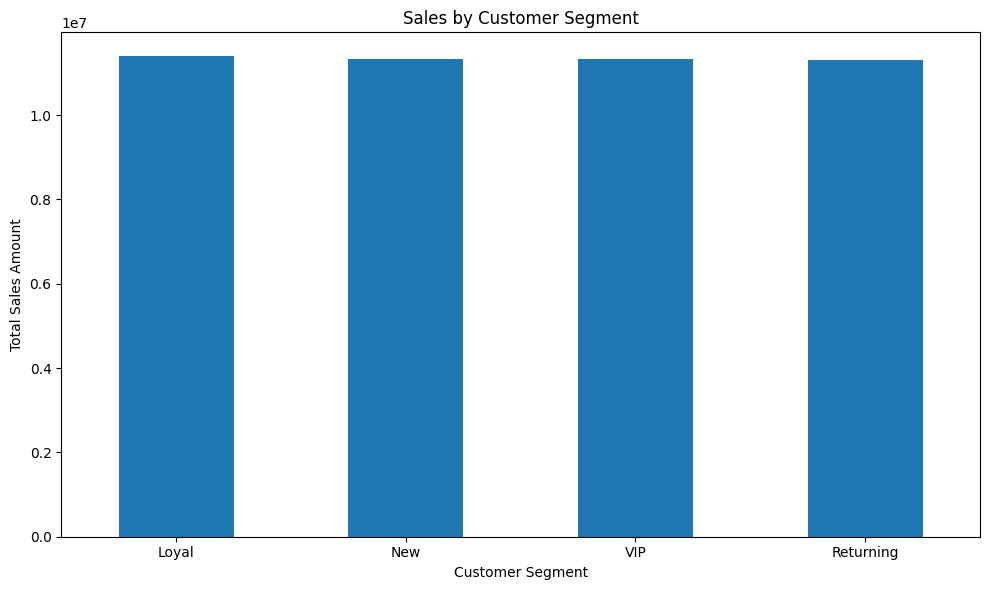

In [ ]:
# Customer Analysis

customer_sales = (
    df.groupby('customer_segment')['sales_amount']
      .sum()
      .sort_values(ascending=False)
)

print("Sales by Customer Segment:")
display(customer_sales)

# Bar Chart
plt.figure(figsize=(10, 6))

customer_sales.plot(kind='bar')

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales by Payment Method:


,sales_amount
payment_method,
Cash,9134699.83
Credit Card,9127113.77
PayPal,9033551.89
Gift Card,9032802.90
Debit Card,9028886.06


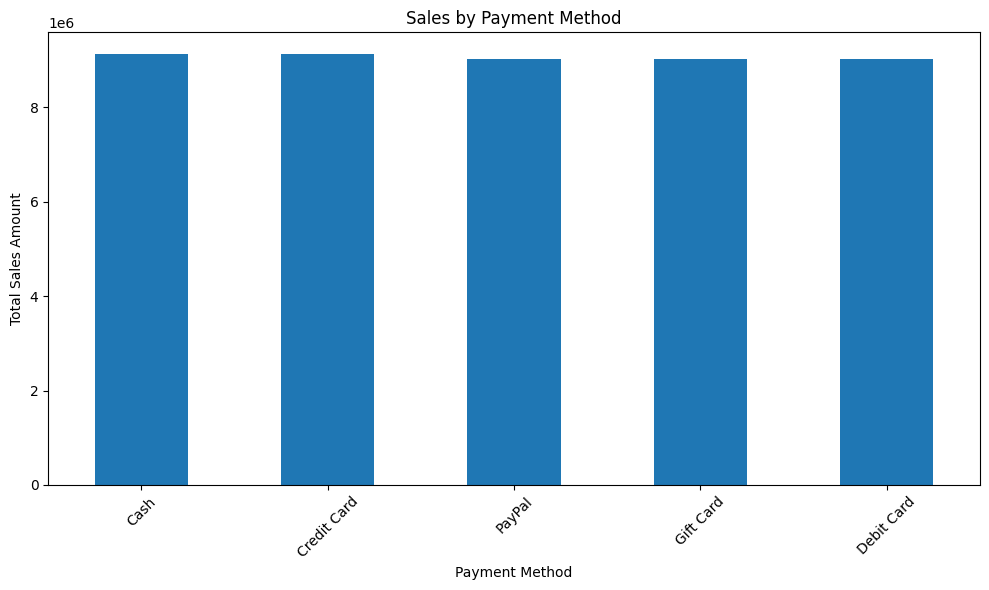

In [ ]:
# Payment Method Analysis

payment_sales = (
    df.groupby('payment_method')['sales_amount']
      .sum()
      .sort_values(ascending=False)
)

print("Sales by Payment Method:")
display(payment_sales)

# Bar Chart
plt.figure(figsize=(10, 6))

payment_sales.plot(kind='bar')

plt.title('Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Region:


,sales_amount
region,
Central,9237924.11
West,9106911.70
North,9049438.11
South,8991262.89
East,8971517.64


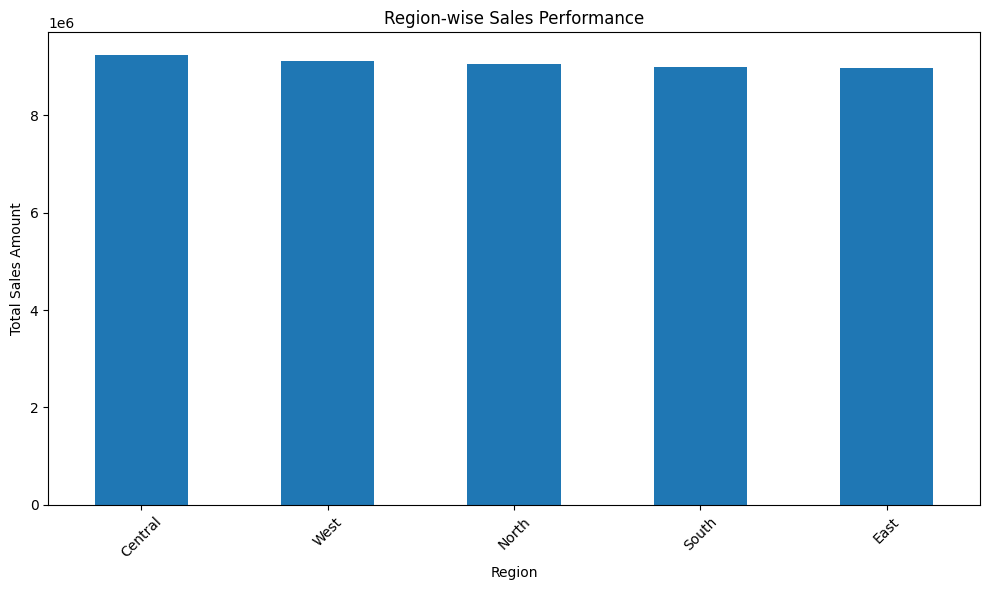

In [ ]:
# Region-wise Sales Analysis

region_sales = (
    df.groupby('region')['sales_amount']
      .sum()
      .sort_values(ascending=False)
)

print("Sales by Region:")
display(region_sales)

# Bar Chart
plt.figure(figsize=(10, 6))

region_sales.plot(kind='bar')

plt.title('Region-wise Sales Performance')
plt.xlabel('Region')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# FINAL BUSINESS INSIGHTS
# ==============================

print("========== BUSINESS INSIGHTS ==========\n")

print("1. Best-performing category: Beauty")
print("   Sales: 6,355,718.23\n")

print("2. Lowest-performing category: Clothing")
print("   Sales: 4,628,379.45\n")

print("3. Best-performing region: Central")
print("   Sales: 9,237,924.11\n")

print("4. Lowest-performing region: East")
print("   Sales: 8,971,517.64\n")

print("5. Highest-sales customer segment: Loyal")
print("   Sales: 11,393,721.23\n")

print("6. Highest-sales payment method: Cash")
print("   Sales: 9,134,699.83")

========== BUSINESS INSIGHTS ==========

1. Best-performing category: Beauty
   Sales: 6,355,718.23

2. Lowest-performing category: Clothing
   Sales: 4,628,379.45

3. Best-performing region: Central
   Sales: 9,237,924.11

4. Lowest-performing region: East
   Sales: 8,971,517.64

5. Highest-sales customer segment: Loyal
   Sales: 11,393,721.23

6. Highest-sales payment method: Cash
   Sales: 9,134,699.83


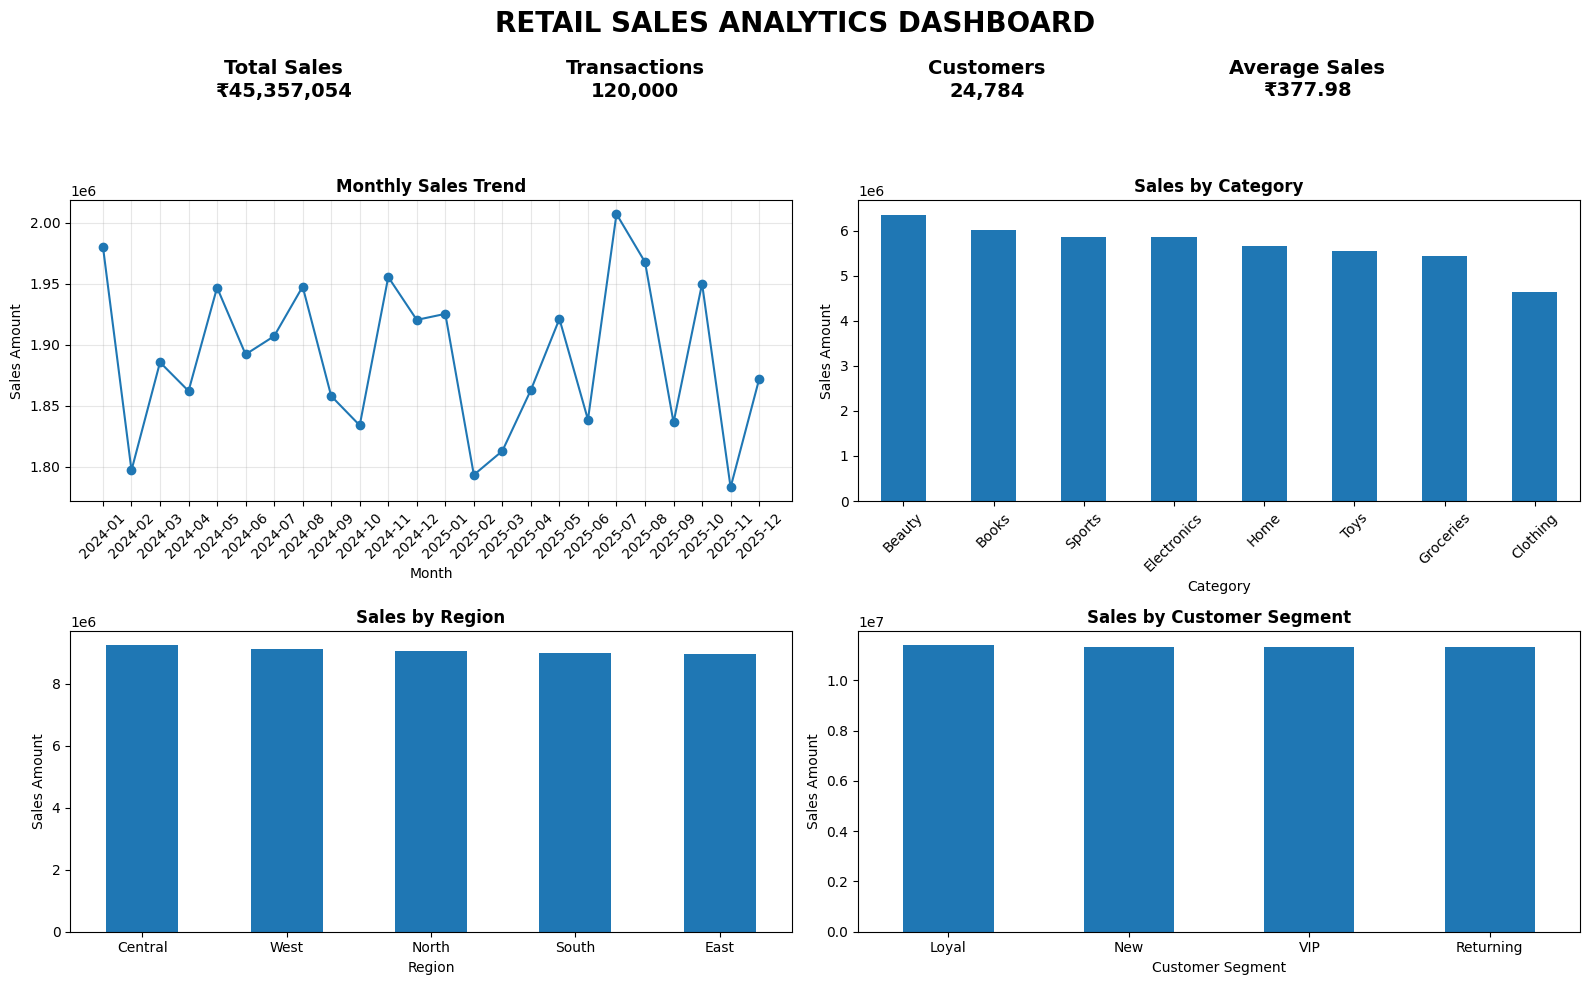

In [ ]:
# ==========================================
# RETAIL SALES ANALYTICS - FINAL DASHBOARD
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Make sure date is in datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create analysis tables
monthly_sales = (
    df.groupby(df['transaction_date'].dt.to_period('M'))['sales_amount']
    .sum()
    .reset_index()
)

monthly_sales['transaction_date'] = monthly_sales['transaction_date'].astype(str)

category_sales = (
    df.groupby('category')['sales_amount']
    .sum()
    .sort_values(ascending=False)
)

region_sales = (
    df.groupby('region')['sales_amount']
    .sum()
    .sort_values(ascending=False)
)

segment_sales = (
    df.groupby('customer_segment')['sales_amount']
    .sum()
    .sort_values(ascending=False)
)

# ==========================================
# CREATE DASHBOARD
# ==========================================

fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    'RETAIL SALES ANALYTICS DASHBOARD',
    fontsize=20,
    fontweight='bold'
)

# -----------------------------
# KPI VALUES
# -----------------------------

total_sales = df['sales_amount'].sum()
total_transactions = df['transaction_id'].nunique()
total_customers = df['customer_id'].nunique()
average_sales = df['sales_amount'].mean()

# KPI 1
fig.text(
    0.18, 0.91,
    f'Total Sales\n₹{total_sales:,.0f}',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# KPI 2
fig.text(
    0.40, 0.91,
    f'Transactions\n{total_transactions:,}',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# KPI 3
fig.text(
    0.62, 0.91,
    f'Customers\n{total_customers:,}',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# KPI 4
fig.text(
    0.82, 0.91,
    f'Average Sales\n₹{average_sales:,.2f}',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# ==========================================
# CHART 1 - MONTHLY SALES
# ==========================================

ax1 = plt.subplot(2, 2, 1)

ax1.plot(
    monthly_sales['transaction_date'],
    monthly_sales['sales_amount'],
    marker='o'
)

ax1.set_title('Monthly Sales Trend', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales Amount')

ax1.tick_params(axis='x', rotation=45)

ax1.grid(True, alpha=0.3)

# ==========================================
# CHART 2 - CATEGORY SALES
# ==========================================

ax2 = plt.subplot(2, 2, 2)

category_sales.plot(
    kind='bar',
    ax=ax2
)

ax2.set_title('Sales by Category', fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Sales Amount')

ax2.tick_params(axis='x', rotation=45)

# ==========================================
# CHART 3 - REGION SALES
# ==========================================

ax3 = plt.subplot(2, 2, 3)

region_sales.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title('Sales by Region', fontweight='bold')
ax3.set_xlabel('Region')
ax3.set_ylabel('Sales Amount')

ax3.tick_params(axis='x', rotation=0)

# ==========================================
# CHART 4 - CUSTOMER SEGMENT
# ==========================================

ax4 = plt.subplot(2, 2, 4)

segment_sales.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title('Sales by Customer Segment', fontweight='bold')
ax4.set_xlabel('Customer Segment')
ax4.set_ylabel('Sales Amount')

ax4.tick_params(axis='x', rotation=0)

# ==========================================
# FINAL FORMATTING
# ==========================================

plt.tight_layout(rect=[0, 0, 1, 0.87])

plt.show()

# Project Objective

The objective of this project is to analyze retail sales data using Python and identify important sales patterns and business trends.

The analysis focuses on:
- Understanding monthly and quarterly sales trends
- Comparing sales across different product categories
- Analyzing customer segments
- Comparing sales across regions
- Understanding sales by payment method
- Identifying high-performing and low-performing areas
- Presenting the findings through visualizations and a dashboard

# Key Findings

1. Beauty is the best-performing product category with sales of approximately 6.36 million.

2. Clothing is the lowest-performing category with sales of approximately 4.63 million.

3. Central is the highest-performing region with sales of approximately 9.24 million.

4. East is the lowest-performing region with sales of approximately 8.97 million.

5. The Loyal customer segment generates the highest sales, approximately 11.39 million.

6. Cash is the payment method associated with the highest sales, approximately 9.13 million.

7. The dataset contains 120,000 transactions and 24,784 unique customers.

8. The monthly sales visualization shows fluctuations in sales across different months, indicating that sales performance varies over time.

# Conclusion and Recommendations

## Conclusion

The retail sales analysis provides useful insights into product, customer, regional, and payment-related sales performance.

The analysis shows that Beauty is the strongest product category, Central is the strongest region, and Loyal customers contribute the highest sales.

The dashboard provides a simple visual summary of the major sales patterns and can help businesses understand their performance more effectively.

## Recommendations

- Focus on maintaining the strong performance of the Beauty category.
- Investigate the lower sales performance of the Clothing category and identify opportunities for improvement.
- Study the strategies used in the Central region and consider applying successful practices to lower-performing regions.
- Develop customer retention strategies to maintain and increase sales from Loyal customers.
- Analyze customer preferences and payment behavior to improve the overall shopping experience.
- Monitor monthly sales trends regularly to identify changes in demand and plan business strategies accordingly.

## Future Scope

The retail sales analysis can be further improved by:

- Adding interactive dashboards using Power BI or Tableau.
- Using machine learning to forecast future sales.
- Performing customer-level analysis to understand purchasing behavior.
- Analyzing seasonal trends and sales patterns.
- Developing automated reports for regular business monitoring.
